TASK 1


In [17]:
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from sklearn.datasets import fetch_california_housing
from sklearn.metrics import (
    mean_absolute_error,
    mean_absolute_percentage_error,
    mean_squared_error,
    r2_score,
)
from sklearn.preprocessing import StandardScaler

# 1. Load Dataset
housing = fetch_california_housing()
X_raw, y_raw = housing.data, housing.target.reshape(-1, 1)

# 2. Reproducible Train (60%), Validation (20%), Test (20%) Split
np.random.seed(9432)
n_samples = len(X_raw)
indices = np.random.permutation(n_samples)

train_end = int(0.60 * n_samples)
val_end = int(0.80 * n_samples)

train_idx, val_idx, test_idx = (
    indices[:train_end],
    indices[train_end:val_end],
    indices[val_end:],
)

X_tr_raw, y_tr_raw = X_raw[train_idx], y_raw[train_idx]
X_v_raw, y_v_raw = X_raw[val_idx], y_raw[val_idx]
X_te_raw, y_te_raw = X_raw[test_idx], y_raw[test_idx]

# 3. Feature Normalization (Fit ONLY on training set)
scaler_X = StandardScaler()
X_tr_scaled = scaler_X.fit_transform(X_tr_raw)
X_v_scaled = scaler_X.transform(X_v_raw)
X_te_scaled = scaler_X.transform(X_te_raw)

# 4. Feature Augmentation (Add Bias Column of 1s)
X_train = np.hstack([np.ones((len(X_tr_scaled), 1)), X_tr_scaled])
X_val = np.hstack([np.ones((len(X_v_scaled), 1)), X_v_scaled])
X_test = np.hstack([np.ones((len(X_te_scaled), 1)), X_te_scaled])

# 5. Target Standardization (Fit ONLY on training set)
scaler_y = StandardScaler()
y_train = scaler_y.fit_transform(y_tr_raw)
y_val = scaler_y.transform(y_v_raw)
y_test = scaler_y.transform(y_te_raw)

print(
    f"Data Split Shapes:\nTrain: {X_train.shape}, Val: {X_val.shape}, Test: {X_test.shape}"
)

Data Split Shapes:
Train: (12384, 9), Val: (4128, 9), Test: (4128, 9)


TASK 2

In [18]:
def train_mini_batch_gd(
    X_tr,
    y_tr,
    X_v,
    y_v,
    learning_rate,
    batch_size,
    max_epochs=1000,
    patience=100,
):
    n_samples, n_features = X_tr.shape
    weights = np.zeros((n_features, 1))

    best_weights = weights.copy()
    best_val_loss = float("inf")
    best_epoch = 0
    patience_counter = 0

    train_loss_history = []
    val_loss_history = []

    for epoch in range(max_epochs):
        # Shuffle training set at start of epoch
        perm = np.random.permutation(n_samples)
        X_tr_shuffled = X_tr[perm]
        y_tr_shuffled = y_tr[perm]

        total_train_loss_sum = 0.0

        for i in range(0, n_samples, batch_size):
            X_batch = X_tr_shuffled[i : i + batch_size]
            y_batch = y_tr_shuffled[i : i + batch_size]
            b_size = len(X_batch)

            # Gradient & Loss Calculation
            y_pred_batch = X_batch @ weights
            error = y_pred_batch - y_batch

            batch_mse = np.mean(error**2)
            total_train_loss_sum += batch_mse * b_size

            gradient = (2 / b_size) * (X_batch.T @ error)

            # Handle gradient instability for extreme learning rates
            if np.isnan(gradient).any() or np.isinf(gradient).any():
                break

            weights -= learning_rate * gradient

        if np.isnan(weights).any() or np.isinf(weights).any():
            break

        # Sample-weighted training MSE
        epoch_train_mse = total_train_loss_sum / n_samples
        train_loss_history.append(epoch_train_mse)

        # Validation MSE calculation
        y_v_pred = X_v @ weights
        epoch_val_mse = np.mean((y_v_pred - y_v) ** 2)
        val_loss_history.append(epoch_val_mse)

        # Early Stopping logic based on best validation loss
        if epoch_val_mse < best_val_loss:
            best_val_loss = epoch_val_mse
            best_weights = weights.copy()
            best_epoch = epoch
            patience_counter = 0
        else:
            patience_counter += 1
            if patience_counter >= patience:
                break

    return best_weights, train_loss_history, val_loss_history, best_epoch

/tmp/ipykernel_2402/2206935355.py:59: RuntimeWarning: overflow encountered in square
  epoch_val_mse = np.mean((y_v_pred - y_v) ** 2)
/tmp/ipykernel_2402/2206935355.py:39: RuntimeWarning: overflow encountered in square
  batch_mse = np.mean(error**2)
/usr/local/lib/python3.12/dist-packages/numpy/_core/_methods.py:127: RuntimeWarning: overflow encountered in reduce
  ret = umr_sum(arr, axis, dtype, out, keepdims, where=where)
/tmp/ipykernel_2402/2206935355.py:40: RuntimeWarning: overflow encountered in scalar add
  total_train_loss_sum += batch_mse * b_size
/tmp/ipykernel_2402/2206935355.py:42: RuntimeWarning: overflow encountered in matmul
  gradient = (2 / b_size) * (X_batch.T @ error)


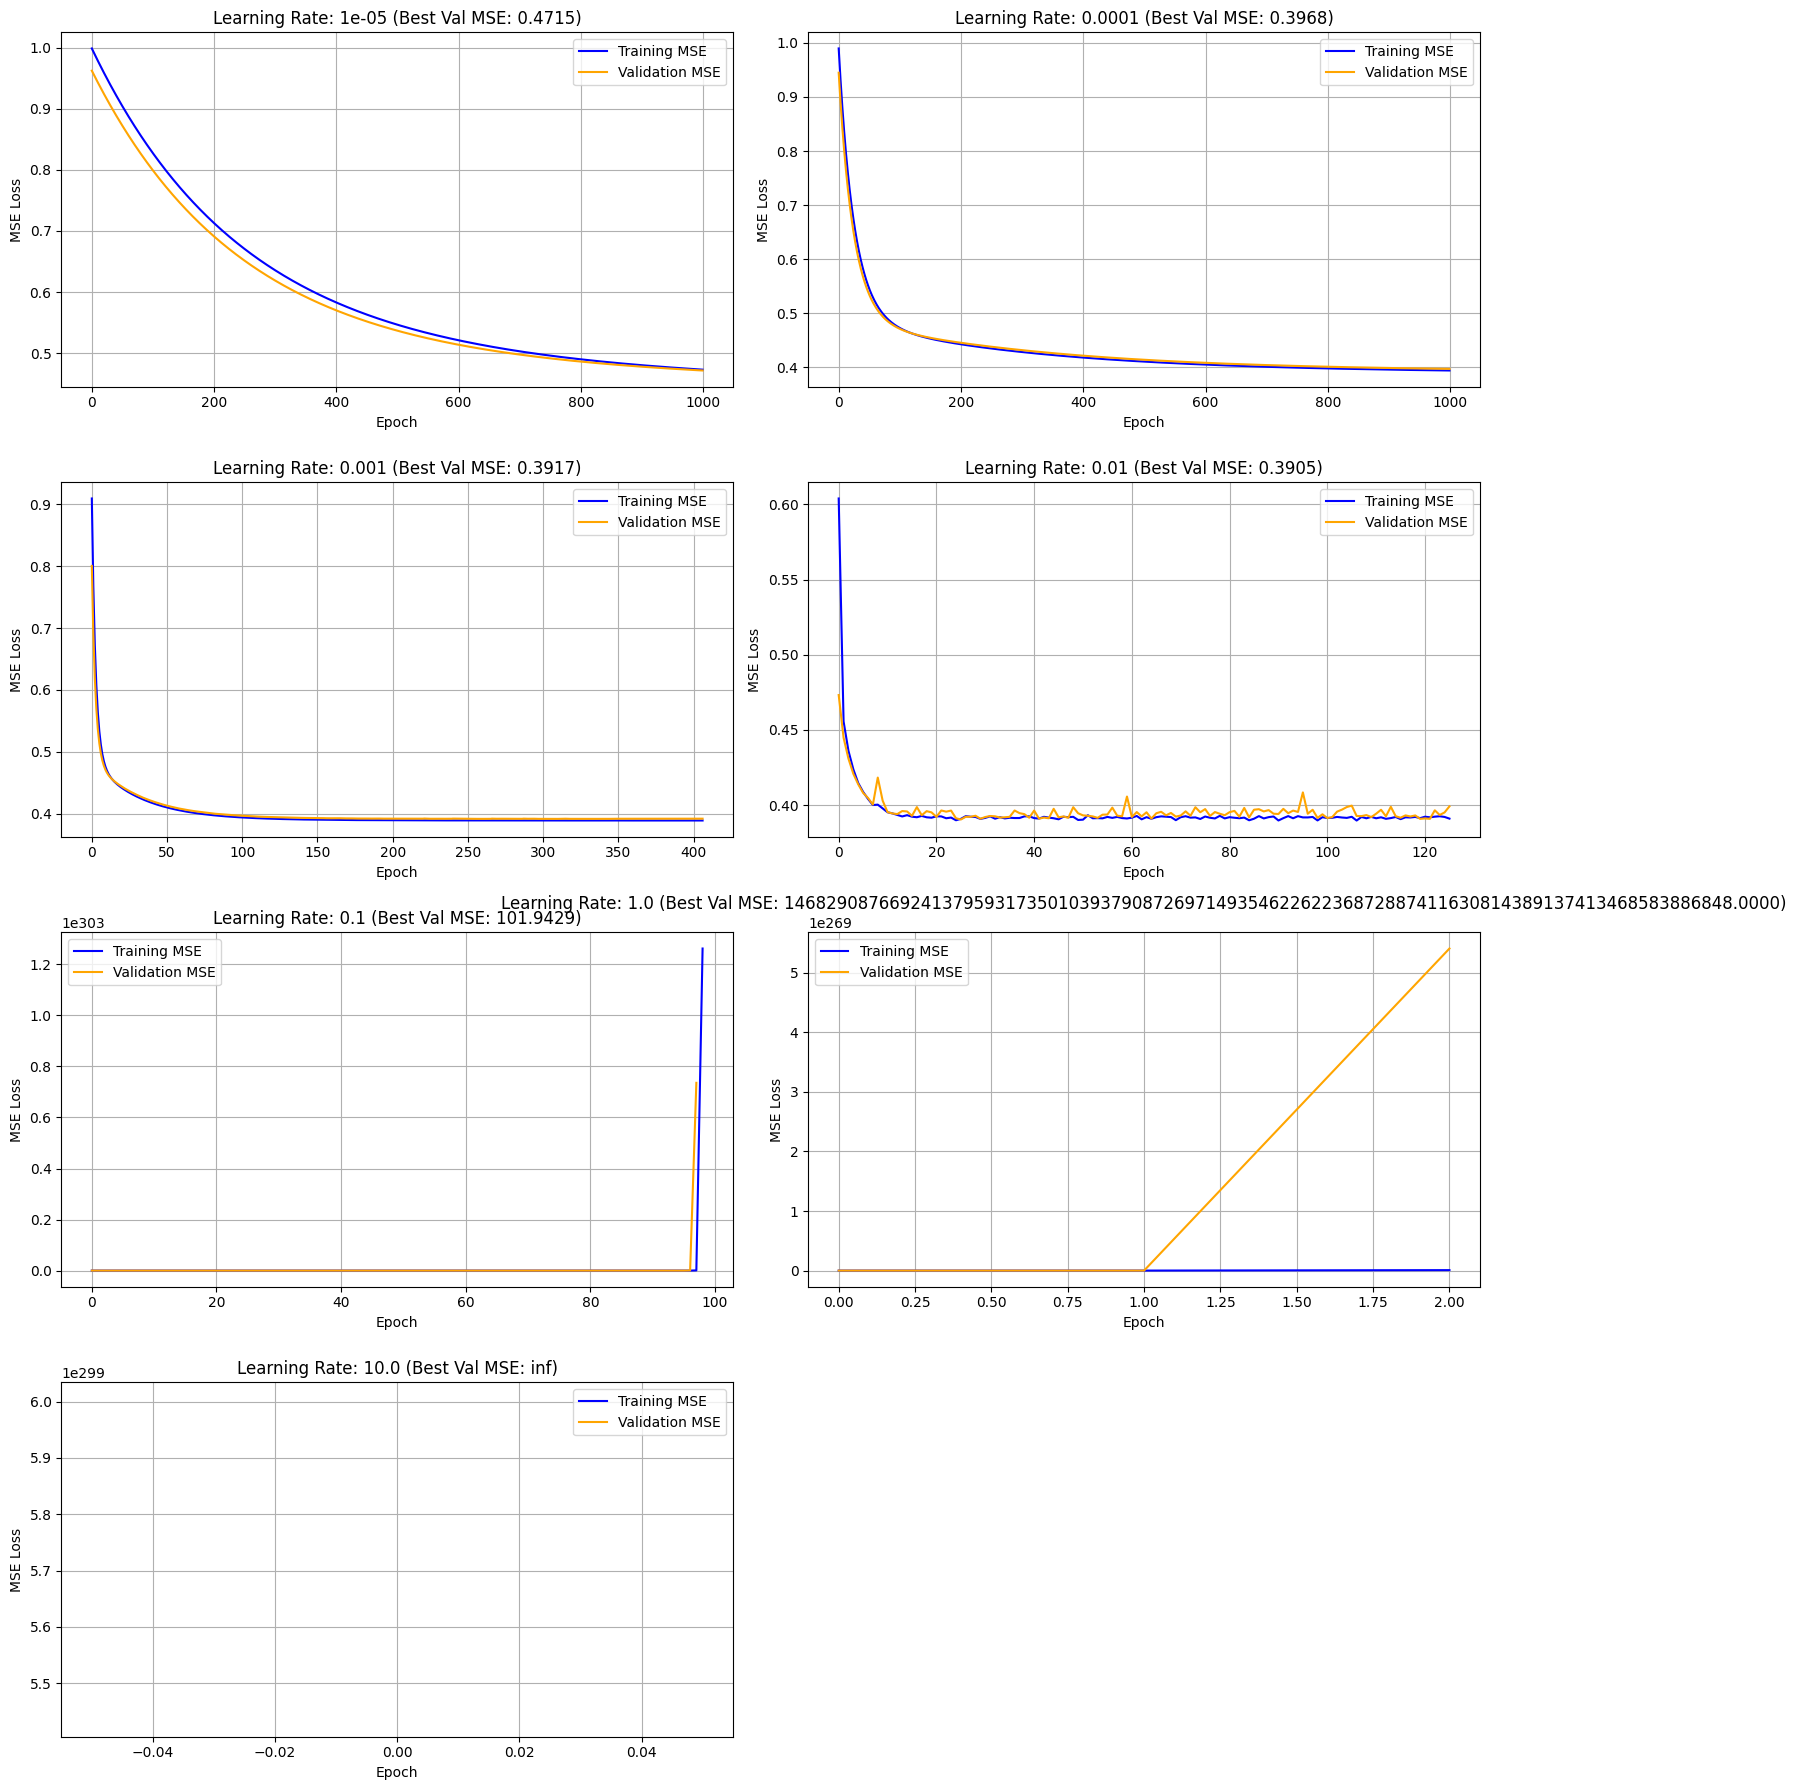

Best Learning Rate based on Validation Performance: 0.01


In [19]:
learning_rates = [1e-5, 1e-4, 1e-3, 1e-2, 1e-1, 1.0, 10.0]
batch_size_t3 = 128

best_lr_overall = None
min_val_loss_overall = float("inf")

plt.figure(figsize=(15, 18))

for idx, lr in enumerate(learning_rates):
    w, tr_loss, v_loss, b_ep = train_mini_batch_gd(
        X_train, y_train, X_val, y_val, learning_rate=lr, batch_size=batch_size_t3
    )

    if v_loss and min(v_loss) < min_val_loss_overall:
        min_val_loss_overall = min(v_loss)
        best_lr_overall = lr

    plt.subplot(4, 2, idx + 1)
    plt.plot(tr_loss, label="Training MSE", color="blue")
    plt.plot(v_loss, label="Validation MSE", color="orange")
    plt.title(f"Learning Rate: {lr} (Best Val MSE: {min(v_loss) if v_loss else 'Diverged':.4f})")
    plt.xlabel("Epoch")
    plt.ylabel("MSE Loss")
    plt.legend()
    plt.grid(True)

plt.tight_layout()
plt.show()

print(f"Best Learning Rate based on Validation Performance: {best_lr_overall}")

/tmp/ipykernel_2402/2206935355.py:40: RuntimeWarning: overflow encountered in scalar add
  total_train_loss_sum += batch_mse * b_size
/tmp/ipykernel_2402/2206935355.py:39: RuntimeWarning: overflow encountered in square
  batch_mse = np.mean(error**2)
/tmp/ipykernel_2402/2206935355.py:59: RuntimeWarning: overflow encountered in square
  epoch_val_mse = np.mean((y_v_pred - y_v) ** 2)


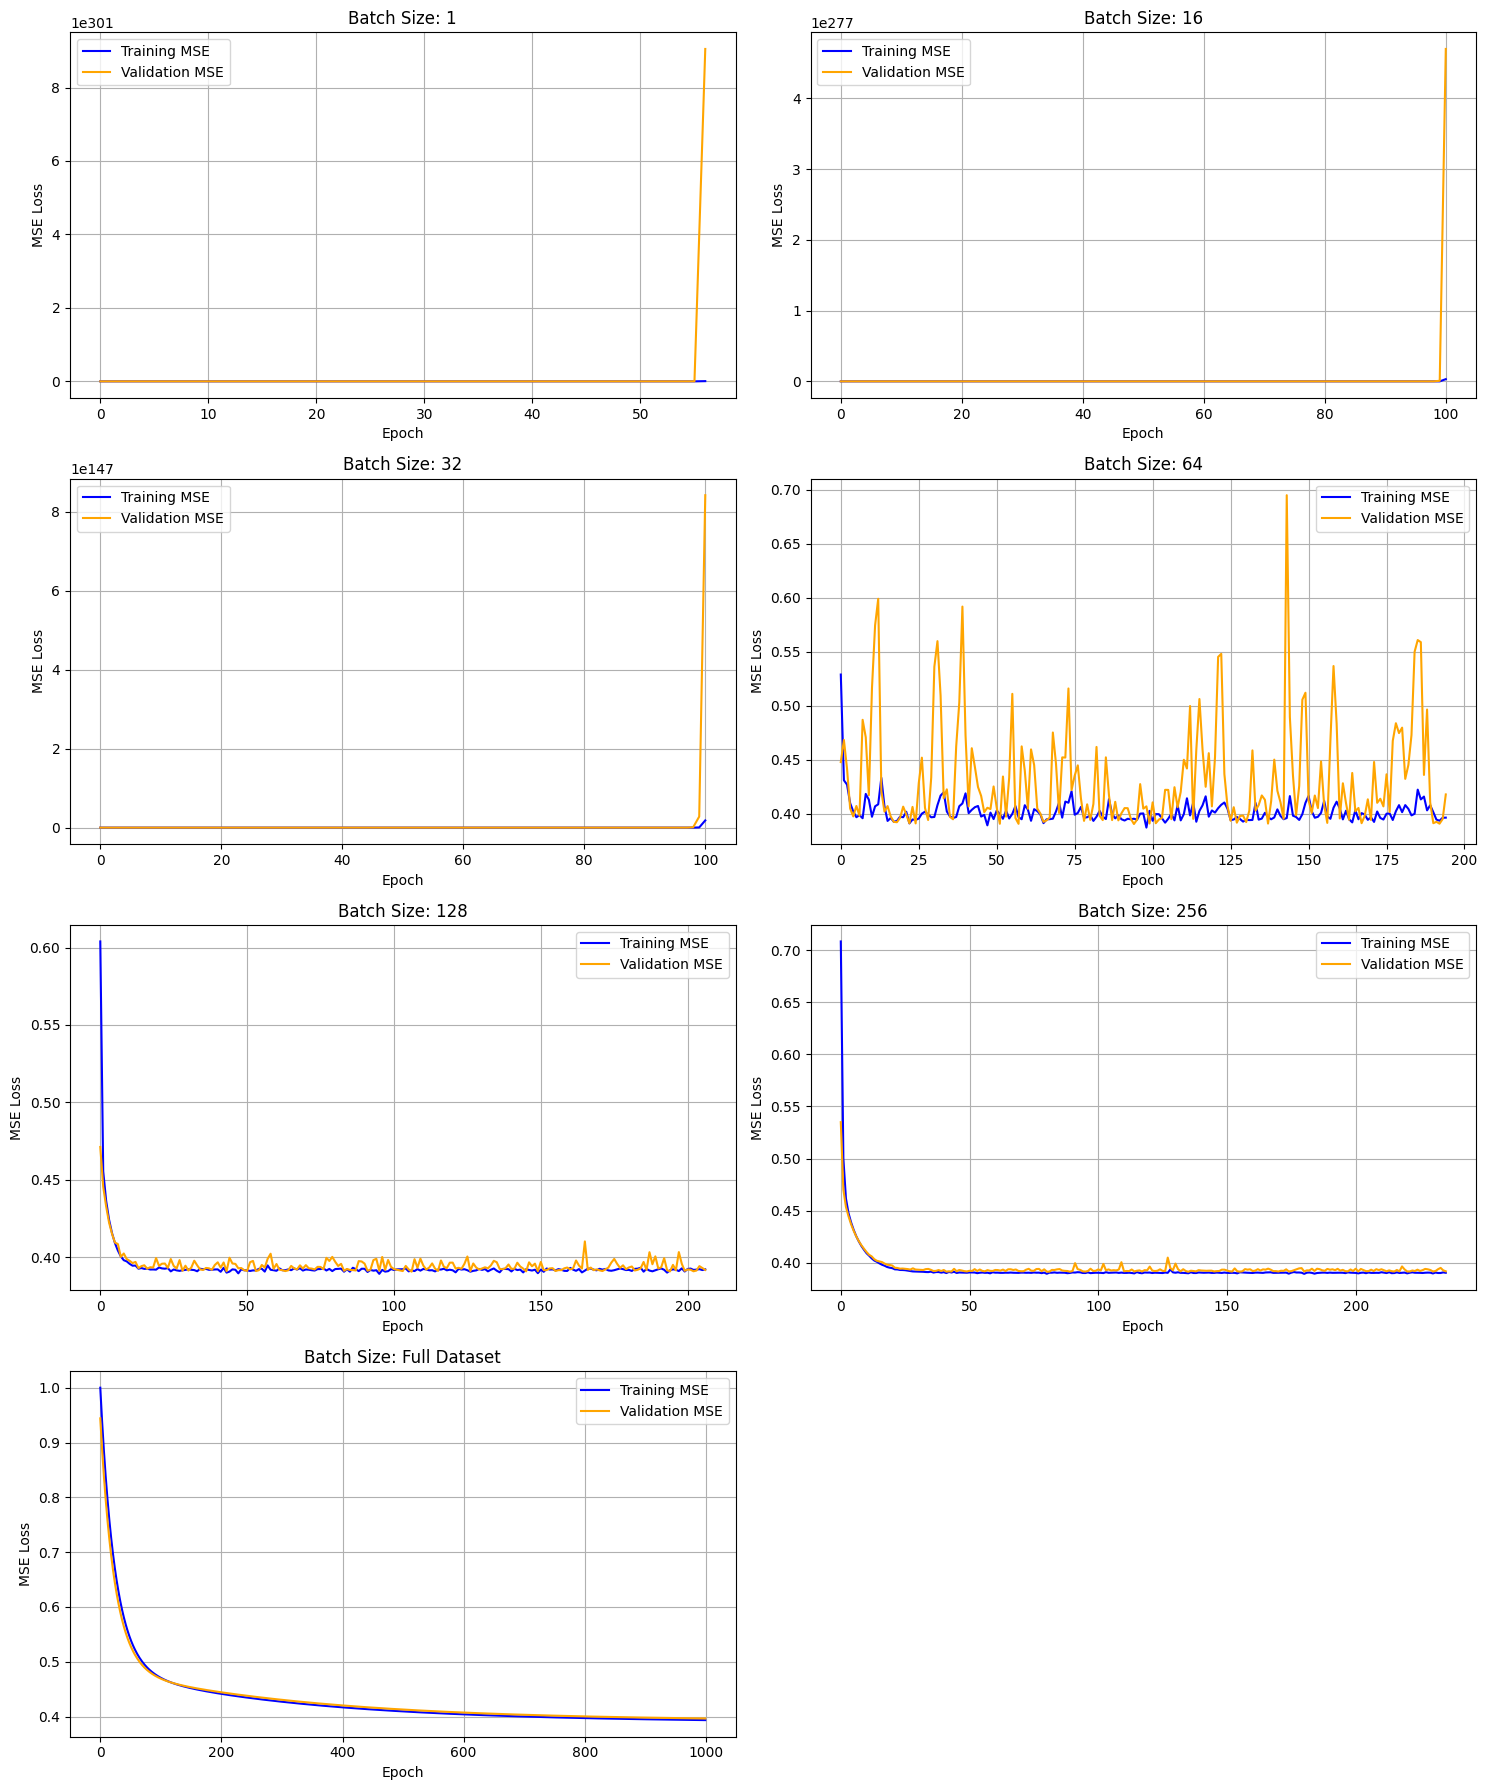

=== Batch Size Performance Summary ===
  Batch Size  Lowest Validation MSE  Best Epoch
           1           2.935399e+08           0
          16           3.512336e+01           0
          32           6.208648e-01           0
          64           3.904677e-01          94
         128           3.905331e-01         106
         256           3.911683e-01         135
Full Dataset           3.963958e-01         999

Selected Best Batch Size: 64


In [20]:
batch_sizes = [1, 16, 32, 64, 128, 256, len(X_train)]
batch_names = ["1", "16", "32", "64", "128", "256", "Full Dataset"]

summary_data = []
best_batch_size = None
min_val_loss_batch = float("inf")
best_model_weights = None

plt.figure(figsize=(15, 18))

for idx, (bs, b_name) in enumerate(zip(batch_sizes, batch_names)):
    w, tr_loss, v_loss, b_ep = train_mini_batch_gd(
        X_train,
        y_train,
        X_val,
        y_val,
        learning_rate=best_lr_overall,
        batch_size=bs,
    )

    lowest_val_mse = v_loss[b_ep]
    summary_data.append(
        {
            "Batch Size": b_name,
            "Lowest Validation MSE": lowest_val_mse,
            "Best Epoch": b_ep,
        }
    )

    if lowest_val_mse < min_val_loss_batch:
        min_val_loss_batch = lowest_val_mse
        best_batch_size = bs
        best_model_weights = w

    plt.subplot(4, 2, idx + 1)
    plt.plot(tr_loss, label="Training MSE", color="blue")
    plt.plot(v_loss, label="Validation MSE", color="orange")
    plt.title(f"Batch Size: {b_name}")
    plt.xlabel("Epoch")
    plt.ylabel("MSE Loss")
    plt.legend()
    plt.grid(True)

plt.tight_layout()
plt.show()

# Display Summary Table
df_summary = pd.DataFrame(summary_data)
print("=== Batch Size Performance Summary ===")
print(df_summary.to_string(index=False))
print(
    f"\nSelected Best Batch Size: {best_batch_size if best_batch_size != len(X_train) else 'Full Dataset'}"
)

=== Final Model Performance Comparison ===
                  RMSE    MAPE     MAE  R-squared
Training Set    0.7227  0.3168  0.5289     0.6101
Validation Set  0.7232  0.3155  0.5342     0.5951
Test Set        0.7302  0.3139  0.5327     0.6038


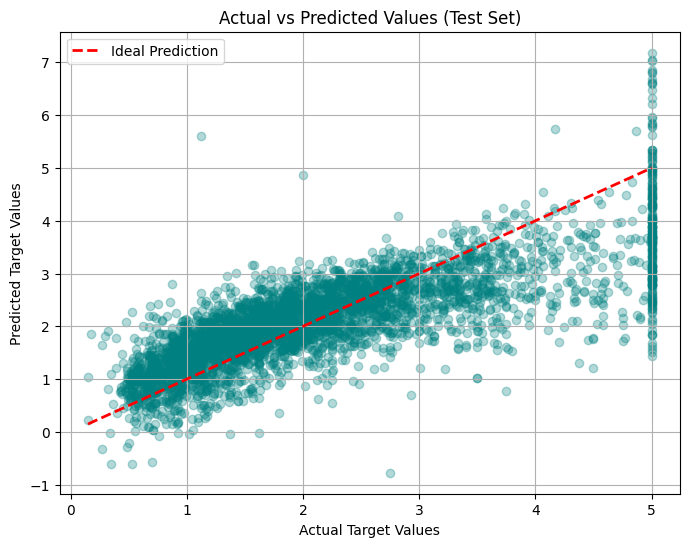

In [21]:
def compute_metrics(X, y_scaled, weights, scaler):
    # Predict in scaled range
    y_pred_scaled = X @ weights
    # Unnormalize back to original range before evaluation
    y_pred_orig = scaler.inverse_transform(y_pred_scaled)
    y_true_orig = scaler.inverse_transform(y_scaled)

    rmse = np.sqrt(mean_squared_error(y_true_orig, y_pred_orig))
    mape = mean_absolute_percentage_error(y_true_orig, y_pred_orig)
    mae = mean_absolute_error(y_true_orig, y_pred_orig)
    r2 = r2_score(y_true_orig, y_pred_orig)

    return rmse, mape, mae, r2, y_true_orig, y_pred_orig


# Evaluate on Train, Val, and Test Sets
metrics_train = compute_metrics(X_train, y_train, best_model_weights, scaler_y)
metrics_val = compute_metrics(X_val, y_val, best_model_weights, scaler_y)
metrics_test = compute_metrics(X_test, y_test, best_model_weights, scaler_y)

# 2. Performance Comparison Table
df_metrics = pd.DataFrame(
    [metrics_train[:4], metrics_val[:4], metrics_test[:4]],
    columns=["RMSE", "MAPE", "MAE", "R-squared"],
    index=["Training Set", "Validation Set", "Test Set"],
)

print("=== Final Model Performance Comparison ===")
print(df_metrics.round(4))

# 3. Scatter Plot: Actual vs Predicted (Test Set)
_, _, _, _, y_test_true, y_test_pred = metrics_test

plt.figure(figsize=(8, 6))
plt.scatter(y_test_true, y_test_pred, alpha=0.3, color="teal")
plt.plot(
    [y_test_true.min(), y_test_true.max()],
    [y_test_true.min(), y_test_true.max()],
    "r--",
    lw=2,
    label="Ideal Prediction",
)
plt.xlabel("Actual Target Values")
plt.ylabel("Predicted Target Values")
plt.title("Actual vs Predicted Values (Test Set)")
plt.legend()
plt.grid(True)
plt.show()